# 05 · Cross-task redundancy & effective dimensions

How many *independent* things does the suite measure? We correlate the 24×N
accuracy matrix (Kendall τ), estimate effective dimensionality (PCA + Horn's
parallel analysis), and corroborate with **question-embedding** similarity.


In [1]:
import nbtools as nb
from nbtools import show_df, show_fig, show_md, run_mod, heavy, REGEN, REPORTS_DIR
print("SAYF_NB_REGEN =", REGEN, "  (heavy GPU/API steps run only when True)")
print("reports dir  :", REPORTS_DIR)

SAYF_NB_REGEN = False   (heavy GPU/API steps run only when True)
reports dir  : /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports


### Correlation structure — `analysis.correlation`
Kendall τ / Spearman / Pearson, bootstrap CI, PCA, clustering.

In [2]:
run_mod("correlation", "analysis.correlation")
show_df("correlation/pairwise_kendall.csv")

matrix: 23 tasks x 10 models


correlation analysis written to /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/correlation/
  redundant pairs (tau>0.85 & CI_lo>0.70): 0
  cumulative variance to 90%: 1 components
  Horn's effective N components: 1
[correlation] recomputed live.


,task,ate,rcm,vsp,ckt,rms,taa,cti_taa,mcq,athena_ate,...,secure_kcv,redsage_frameworks,redsage_generals,redsage_skills,redsage_cli,redsage_kali,cybermetric,mmlu_cs,secbench,seceval
0,ate,1.0000,0.2357,0.4529,0.7071,0.2828,0.2440,0.5006,0.8014,0.2357,...,0.4529,0.6128,0.5657,0.7542,0.6600,0.6128,0.6128,0.7475,0.6128,0.3575
1,rcm,0.2357,1.0000,0.2247,0.2444,0.3778,0.4600,0.2247,0.3778,0.6000,...,0.0449,0.3778,0.2444,0.4222,0.3333,0.4667,0.2889,0.3410,0.2889,0.2697
2,vsp,0.4529,0.2247,1.0000,0.5843,0.5843,0.4420,0.6591,0.4495,0.4495,...,0.1591,0.6293,0.5843,0.4045,0.3146,0.4495,0.4495,0.5977,0.4495,0.5227
3,ckt,0.7071,0.2444,0.5843,1.0000,0.4222,0.3220,0.7191,0.8667,0.4667,...,0.5394,0.8667,0.8222,0.8222,0.7333,0.6889,0.8667,0.7047,0.8667,0.4495
4,rms,0.2828,0.3778,0.5843,0.4222,1.0000,0.6901,0.5394,0.2889,0.5111,...,-0.0449,0.4667,0.4222,0.2444,0.1556,0.2889,0.2889,0.3410,0.2889,0.1798
5,taa,0.2440,0.4600,0.4420,0.3220,0.6901,1.0000,0.5350,0.2760,0.5981,...,-0.1163,0.4600,0.4140,0.2300,0.1380,0.2300,0.2760,0.1882,0.2760,0.1163
6,cti_taa,0.5006,0.2247,0.6591,0.7191,0.5394,0.5350,1.0000,0.6742,0.5394,...,0.2500,0.7641,0.8090,0.6293,0.5394,0.4944,0.6742,0.4138,0.6742,0.3864
7,mcq,0.8014,0.3778,0.4495,0.8667,0.2889,0.2760,0.6742,1.0000,0.4222,...,0.5843,0.8222,0.7778,0.9556,0.8667,0.8222,0.8222,0.7502,0.8222,0.4944
8,athena_ate,0.2357,0.6000,0.4495,0.4667,0.5111,0.5981,0.5394,0.4222,1.0000,...,0.1798,0.6000,0.5556,0.4667,0.3778,0.4222,0.5111,0.2501,0.5111,0.2247
9,athena_rcm,0.4243,0.6444,0.5843,0.6000,0.6444,0.4140,0.4944,0.5556,0.6000,...,0.3146,0.6444,0.5111,0.6000,0.5111,0.6444,0.5556,0.6138,0.5556,0.3596


,task,ate,rcm,vsp,ckt,rms,taa,cti_taa,mcq,athena_ate,...,secure_kcv,redsage_frameworks,redsage_generals,redsage_skills,redsage_cli,redsage_kali,cybermetric,mmlu_cs,secbench,seceval
0,ate,1.0000,0.2357,0.4529,0.7071,0.2828,0.2440,0.5006,0.8014,0.2357,...,0.4529,0.6128,0.5657,0.7542,0.6600,0.6128,0.6128,0.7475,0.6128,0.3575
1,rcm,0.2357,1.0000,0.2247,0.2444,0.3778,0.4600,0.2247,0.3778,0.6000,...,0.0449,0.3778,0.2444,0.4222,0.3333,0.4667,0.2889,0.3410,0.2889,0.2697
2,vsp,0.4529,0.2247,1.0000,0.5843,0.5843,0.4420,0.6591,0.4495,0.4495,...,0.1591,0.6293,0.5843,0.4045,0.3146,0.4495,0.4495,0.5977,0.4495,0.5227
3,ckt,0.7071,0.2444,0.5843,1.0000,0.4222,0.3220,0.7191,0.8667,0.4667,...,0.5394,0.8667,0.8222,0.8222,0.7333,0.6889,0.8667,0.7047,0.8667,0.4495
4,rms,0.2828,0.3778,0.5843,0.4222,1.0000,0.6901,0.5394,0.2889,0.5111,...,-0.0449,0.4667,0.4222,0.2444,0.1556,0.2889,0.2889,0.3410,0.2889,0.1798
5,taa,0.2440,0.4600,0.4420,0.3220,0.6901,1.0000,0.5350,0.2760,0.5981,...,-0.1163,0.4600,0.4140,0.2300,0.1380,0.2300,0.2760,0.1882,0.2760,0.1163
6,cti_taa,0.5006,0.2247,0.6591,0.7191,0.5394,0.5350,1.0000,0.6742,0.5394,...,0.2500,0.7641,0.8090,0.6293,0.5394,0.4944,0.6742,0.4138,0.6742,0.3864
7,mcq,0.8014,0.3778,0.4495,0.8667,0.2889,0.2760,0.6742,1.0000,0.4222,...,0.5843,0.8222,0.7778,0.9556,0.8667,0.8222,0.8222,0.7502,0.8222,0.4944
8,athena_ate,0.2357,0.6000,0.4495,0.4667,0.5111,0.5981,0.5394,0.4222,1.0000,...,0.1798,0.6000,0.5556,0.4667,0.3778,0.4222,0.5111,0.2501,0.5111,0.2247
9,athena_rcm,0.4243,0.6444,0.5843,0.6000,0.6444,0.4140,0.4944,0.5556,0.6000,...,0.3146,0.6444,0.5111,0.6000,0.5111,0.6444,0.5556,0.6138,0.5556,0.3596


### Effective dimensions + redundant pairs

In [3]:
import json
eff = json.loads((REPORTS_DIR / "correlation/effective_dimensions.json").read_text())
print(json.dumps(eff, indent=2))
show_md("correlation/redundant_pairs.md")

{
  "explained_variance_ratio": [
    0.9626101823162886,
    0.021896654305910482,
    0.008254833918847968,
    0.002425658974658369,
    0.0018735749921313673,
    0.0012915714522304341,
    0.00078162275672778,
    0.000628430754540589,
    0.0001397313231326754,
    9.773920553172282e-05
  ],
  "null_variance_ratio_p95": [
    0.25959387603739265,
    0.20422678337691283,
    0.16570206410806373,
    0.13631022481290617,
    0.11408805382106123,
    0.09270058233499567,
    0.07383267333130607,
    0.05891290398734324,
    0.043097975313651615,
    0.028597223984304875
  ],
  "cumulative_variance": [
    0.9626101823162886,
    0.9845068366221991,
    0.992761670541047,
    0.9951873295157054,
    0.9970609045078368,
    0.9983524759600673,
    0.999134098716795,
    0.9997625294713356,
    0.9999022607944683,
    1.0
  ],
  "n_for_target": 1,
  "target": 0.9,
  "horn_n": 1
}


# Redundant sub-task pairs (Kendall τ > 0.85, bootstrap 95% CI lower bound > 0.70)

| τ | 95% CI | task A | task B | same parent? |
|---|---|---|---|---|
| (no pair clears the bar) |

### Correlation figures — `analysis.make_corr_plots`

figures written to /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/figures/
[make_corr_plots] recomputed live.


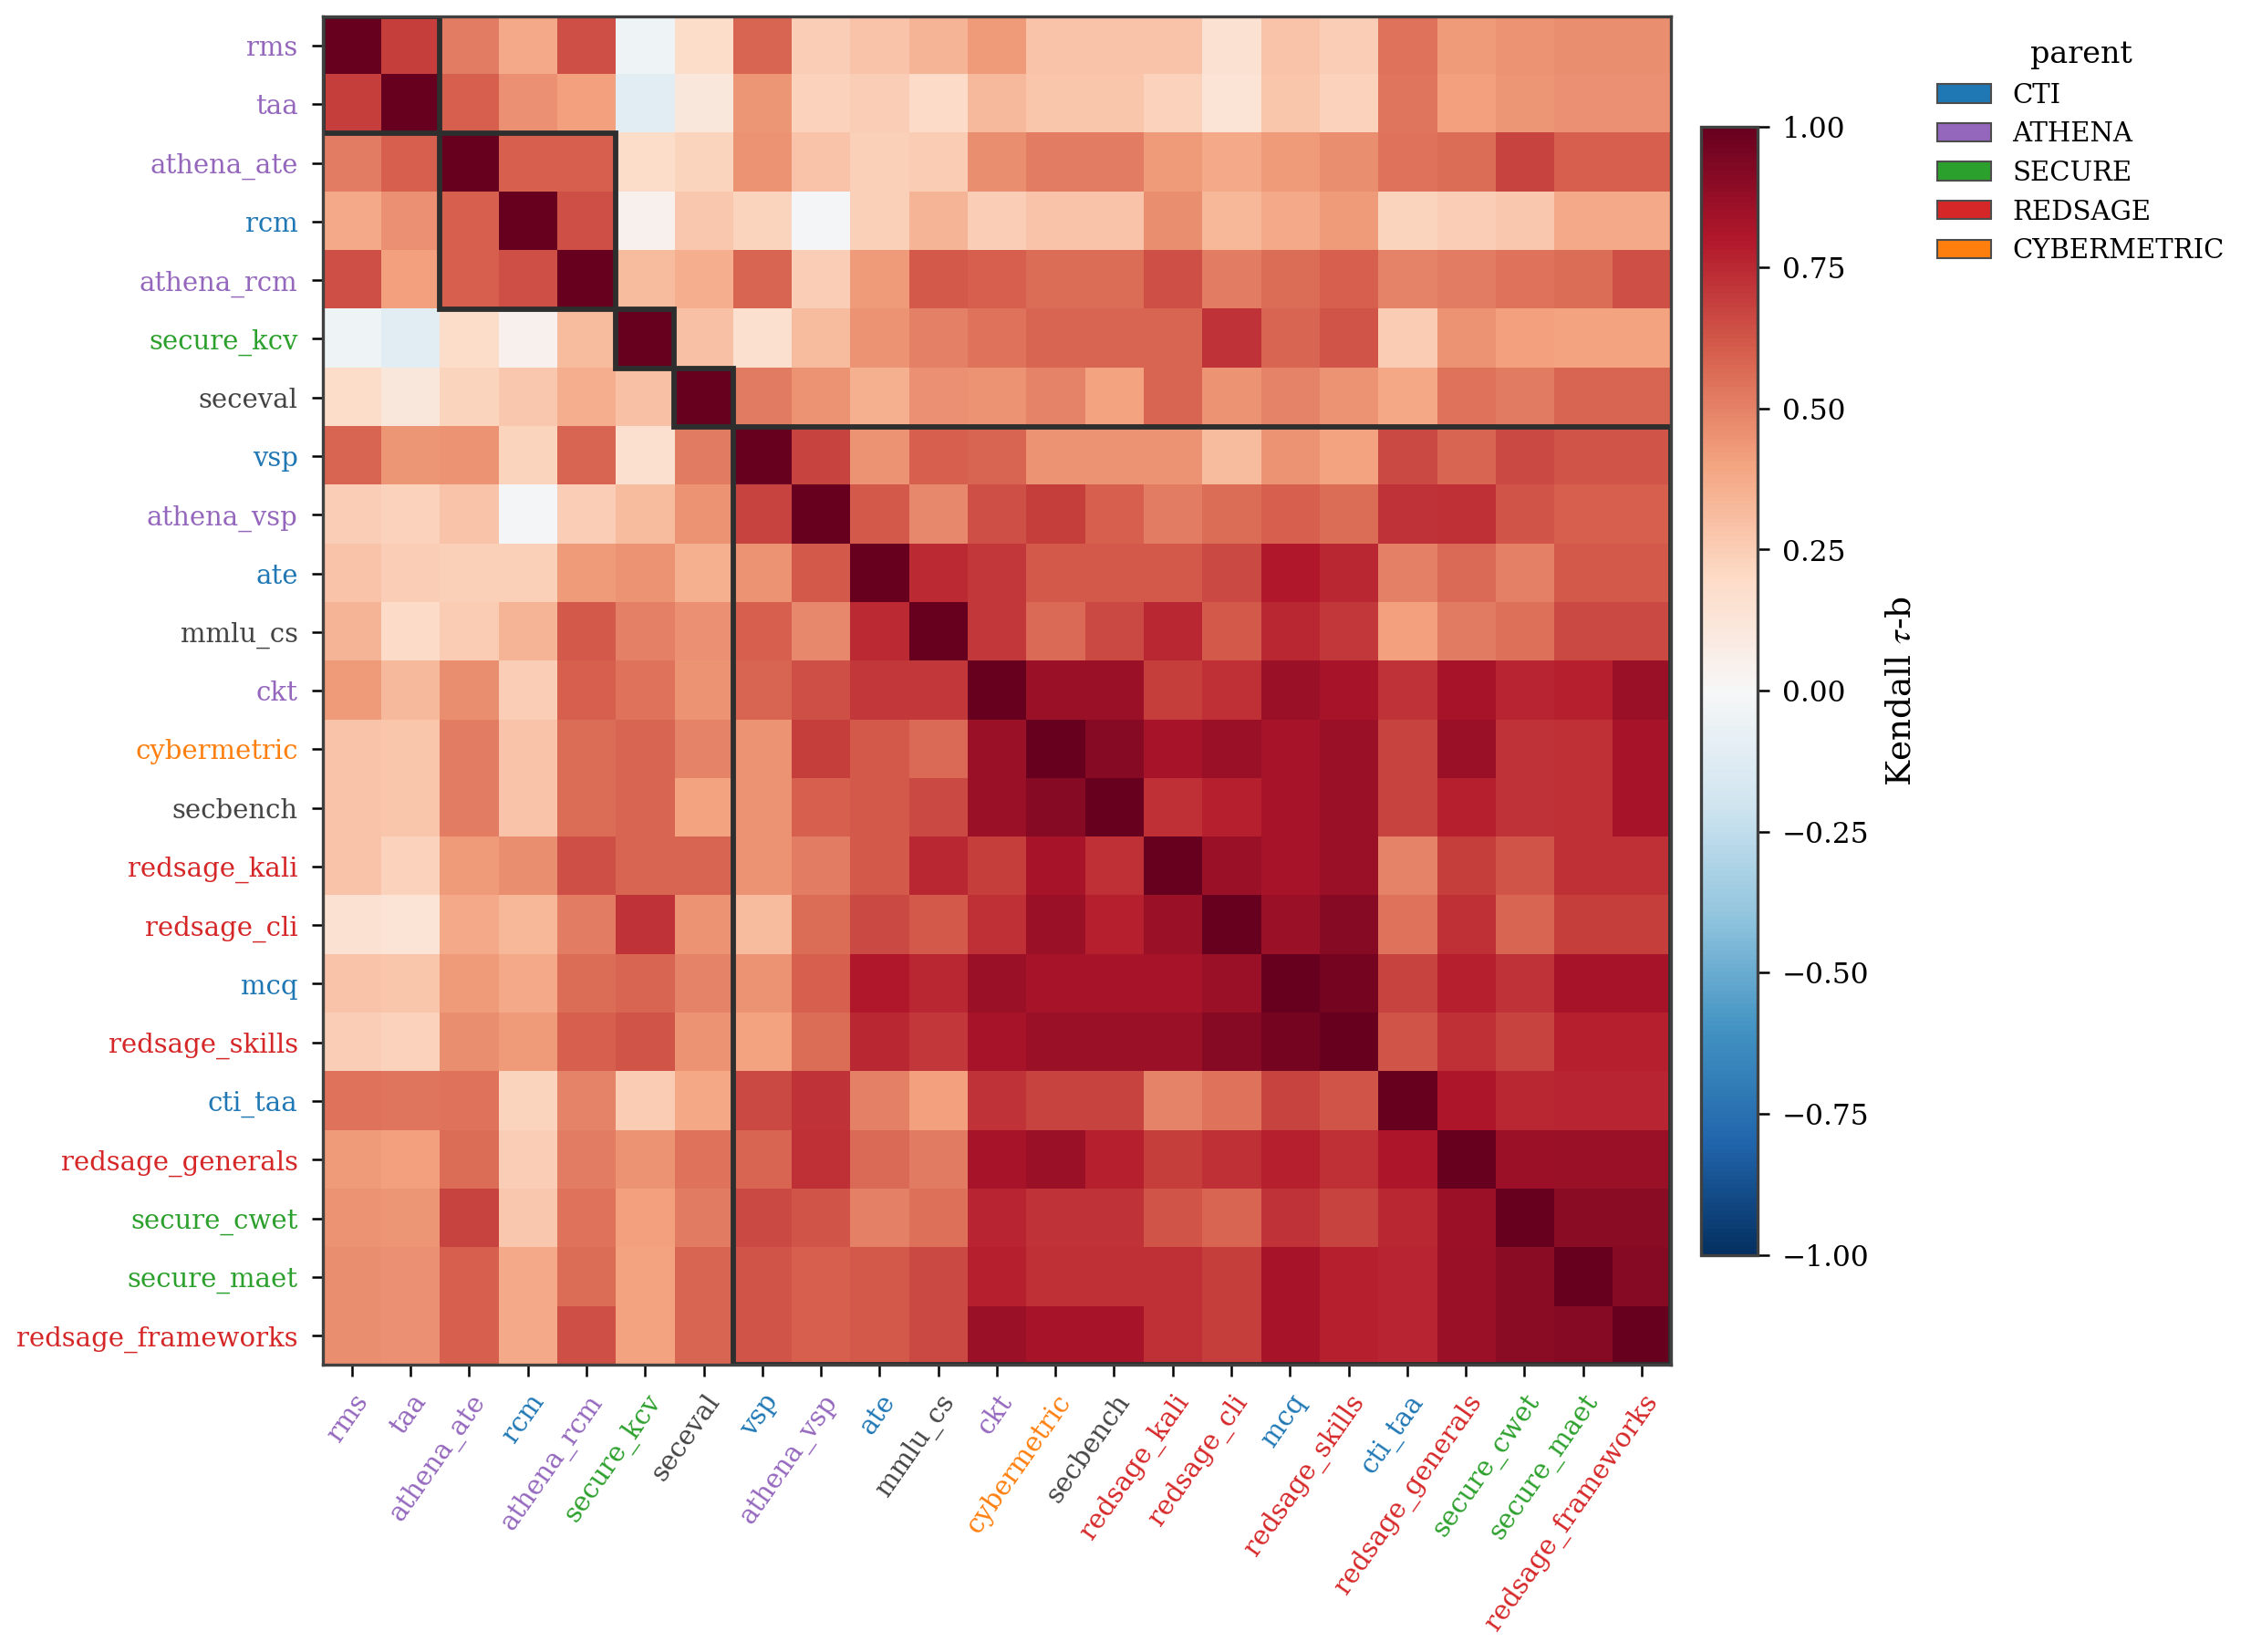

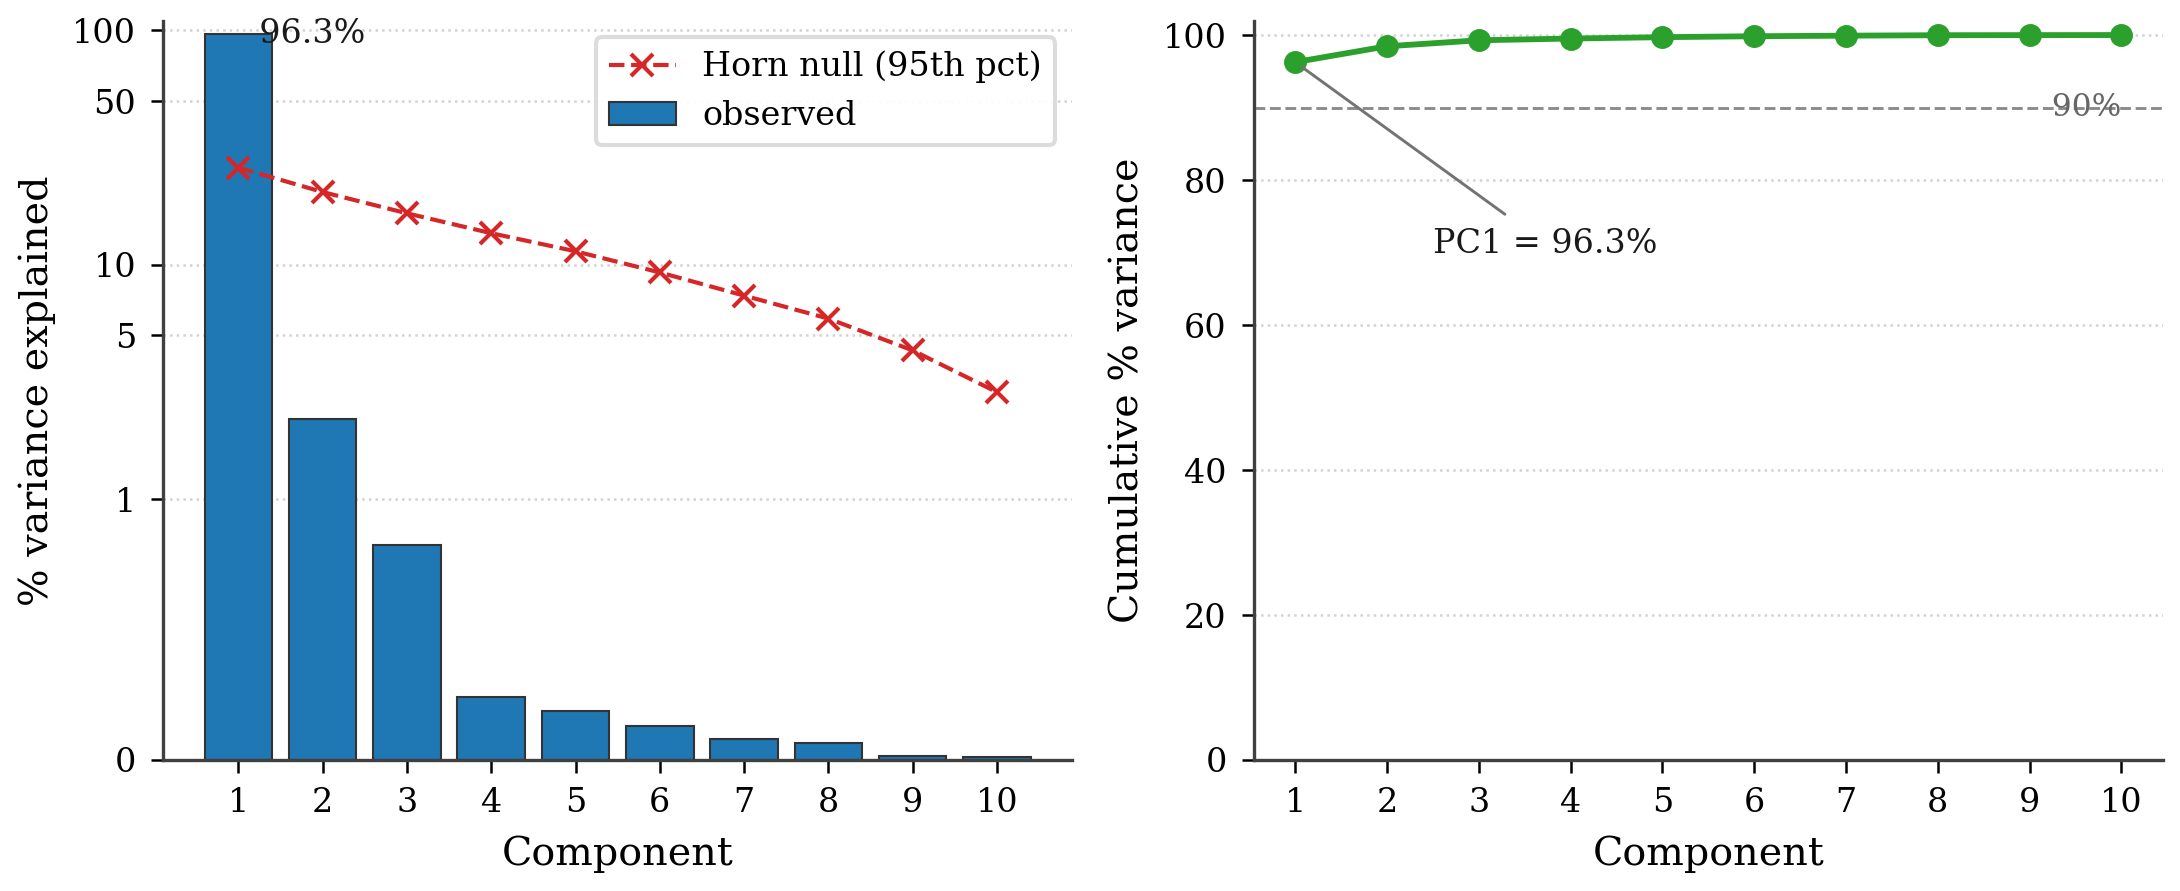

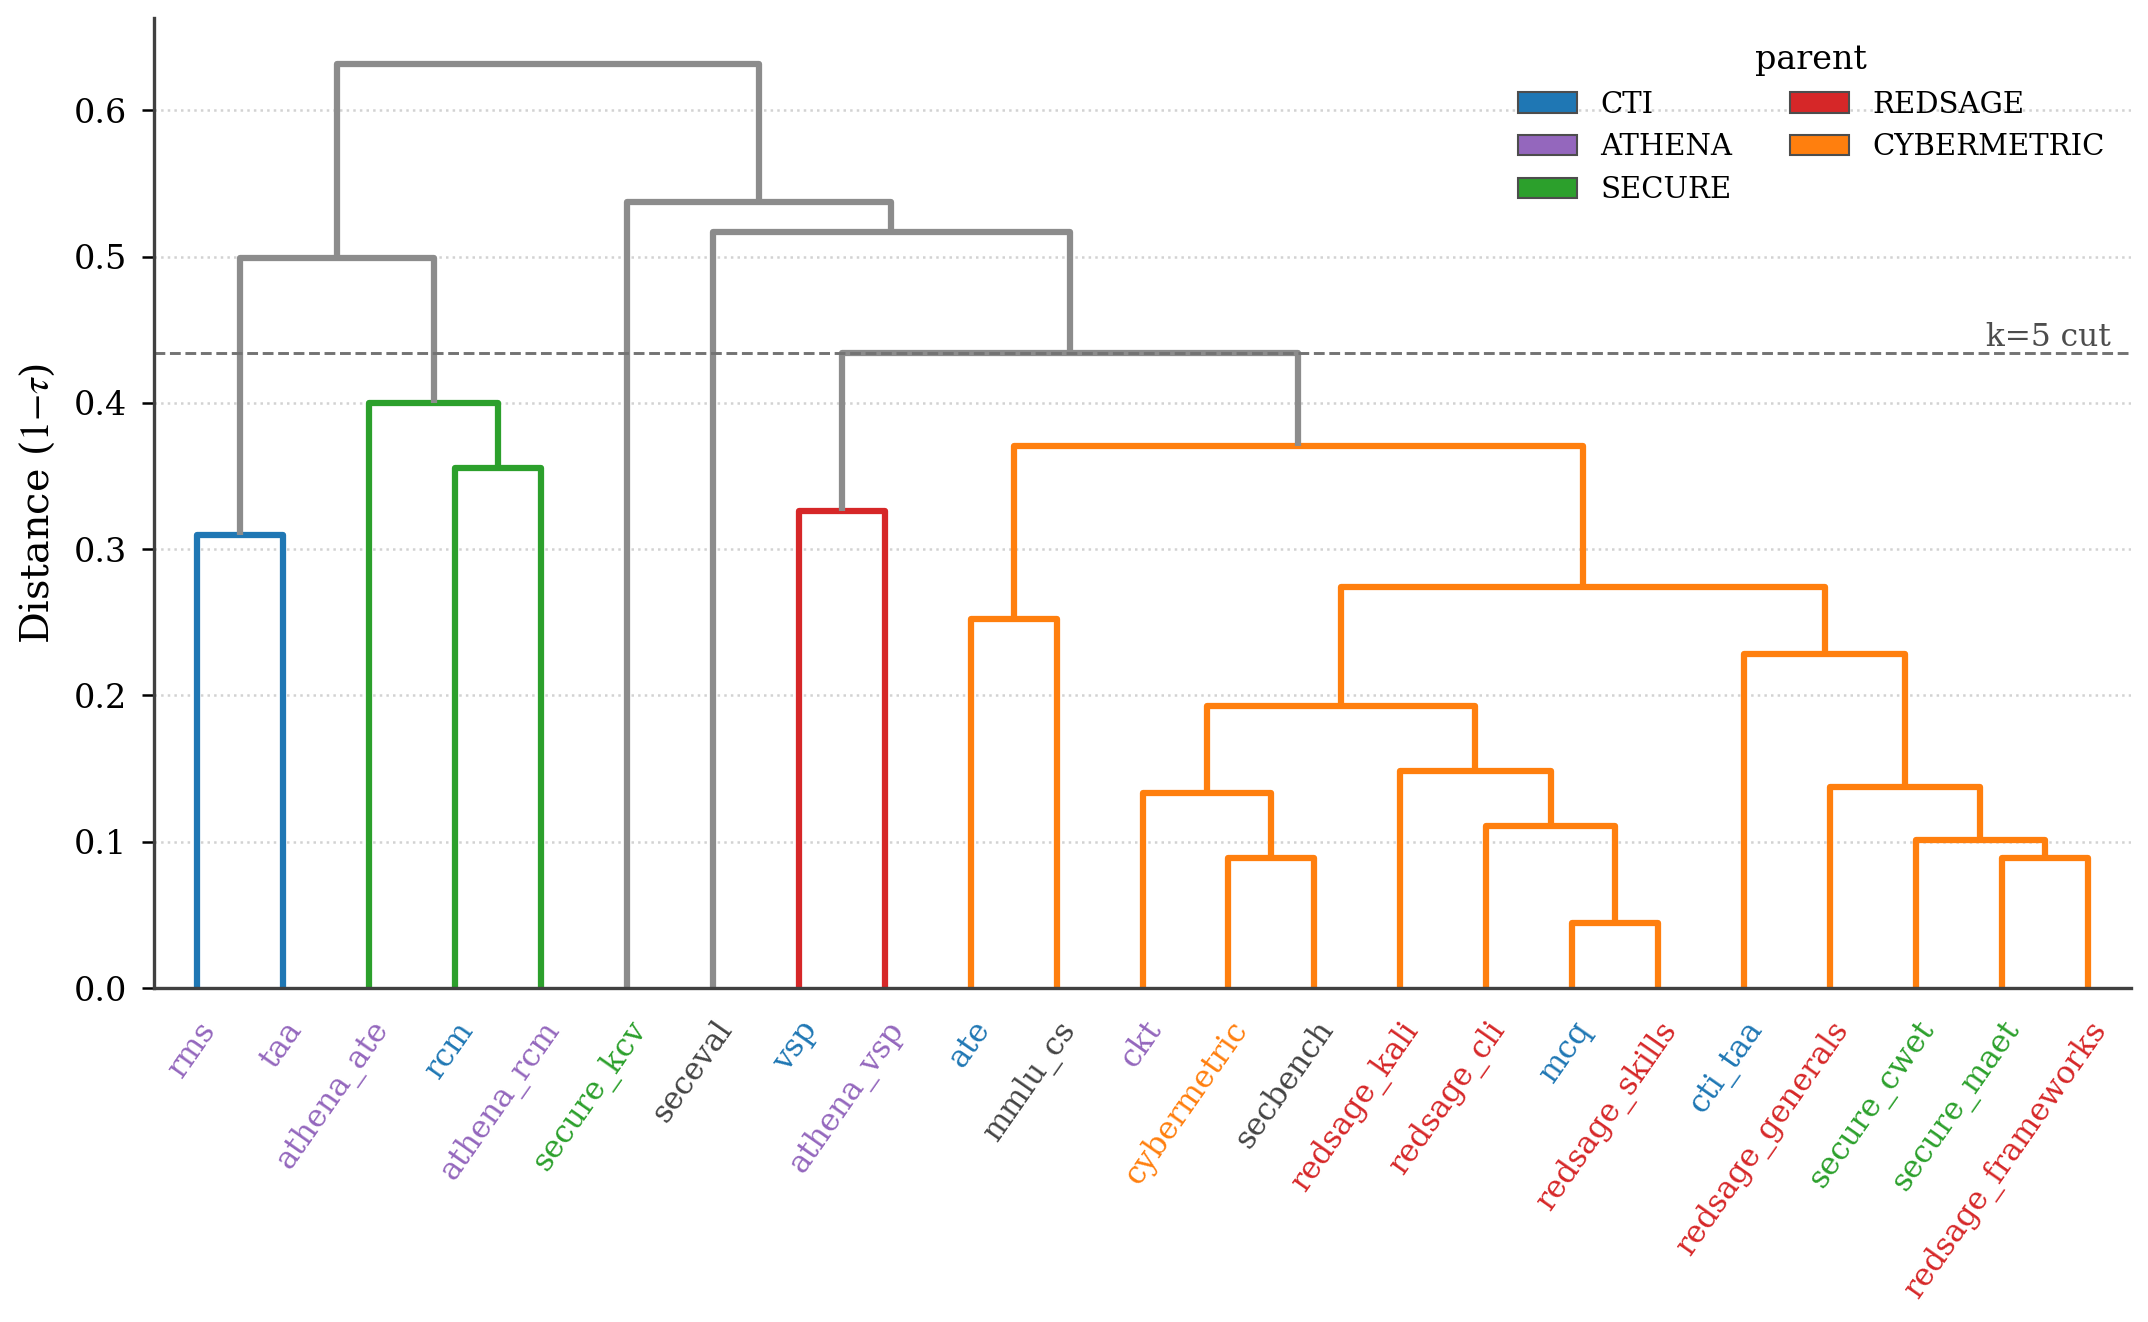

In [4]:
run_mod("make_corr_plots", "analysis.make_corr_plots")
show_fig("kendall_heatmap_clustered.png")
show_fig("pca_scree.png")
show_fig("dendrogram.png")

### Question embeddings — `analysis.embed`  *(heavy · GPU)*
Off by default — rendered from cached `embeddings/`. `SAYF_NB_REGEN=1` (GPU) to
recompute sentence-transformer embeddings.


In [5]:
if heavy("embed"):
    run_mod("embed", "analysis.embed")

[embed] heavy step skipped — rendering cached artifact. Set SAYF_NB_REGEN=1 to recompute (needs GPU/API key).


### Semantic redundancy — `embedding_correlation` + `make_embed_plots`
Centroid similarity, EVoC clustering, Mantel test vs Kendall τ.

=== centroid similarity ===


  centroids for 23/23 tasks; matrix saved
  Mantel r=0.4775  p=0.0010

=== EVoC clustering ===


  X.shape = (48613, 768)
[embedding_correlation] live recompute unavailable (ModuleNotFoundError: No module named 'evoc'); using cached reports/.


figures written to /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/figures/
[make_embed_plots] recomputed live.


,task,ate,rcm,vsp,ckt,rms,taa,cti_taa,mcq,athena_ate,...,secure_kcv,redsage_frameworks,redsage_generals,redsage_skills,redsage_cli,redsage_kali,cybermetric,mmlu_cs,secbench,seceval
0,ate,1.0000,0.7626,0.6838,0.7163,0.8070,0.7542,0.7456,0.7210,0.8330,...,0.7062,0.7472,0.7224,0.7300,0.6739,0.7044,0.7049,0.6301,0.7027,0.7113
1,rcm,0.7626,1.0000,0.7962,0.7617,0.7552,0.7833,0.7632,0.7616,0.7661,...,0.8241,0.8480,0.7928,0.8315,0.7807,0.8020,0.7886,0.7245,0.7953,0.8163
2,vsp,0.6838,0.7962,1.0000,0.7157,0.6689,0.6666,0.6786,0.7051,0.6644,...,0.7149,0.7212,0.6922,0.7112,0.6838,0.7005,0.6940,0.6392,0.6989,0.6640
3,ckt,0.7163,0.7617,0.7157,1.0000,0.8164,0.7341,0.7269,0.9718,0.7978,...,0.7102,0.8654,0.8566,0.8285,0.8098,0.8322,0.8469,0.7056,0.8543,0.8000
4,rms,0.8070,0.7552,0.6689,0.8164,1.0000,0.7494,0.7287,0.8133,0.9264,...,0.6941,0.7978,0.7763,0.7744,0.7396,0.7614,0.7676,0.6558,0.7649,0.7979
5,taa,0.7542,0.7833,0.6666,0.7341,0.7494,1.0000,0.8887,0.7209,0.7524,...,0.7346,0.7661,0.7422,0.7561,0.7040,0.7223,0.7427,0.6541,0.7234,0.7138
6,cti_taa,0.7456,0.7632,0.6786,0.7269,0.7287,0.8887,1.0000,0.7083,0.7208,...,0.7035,0.7484,0.7223,0.7333,0.6764,0.6967,0.7222,0.6377,0.7047,0.6842
7,mcq,0.7210,0.7616,0.7051,0.9718,0.8133,0.7209,0.7083,1.0000,0.7956,...,0.6949,0.8825,0.8750,0.8469,0.8292,0.8494,0.8637,0.7100,0.8692,0.8220
8,athena_ate,0.8330,0.7661,0.6644,0.7978,0.9264,0.7524,0.7208,0.7956,1.0000,...,0.6864,0.7957,0.7709,0.7777,0.7405,0.7605,0.7588,0.6489,0.7608,0.7826
9,athena_rcm,0.7309,0.9252,0.7640,0.7906,0.7594,0.7506,0.7336,0.7755,0.7463,...,0.7766,0.8289,0.7713,0.7976,0.7489,0.7721,0.7694,0.6849,0.7716,0.7897


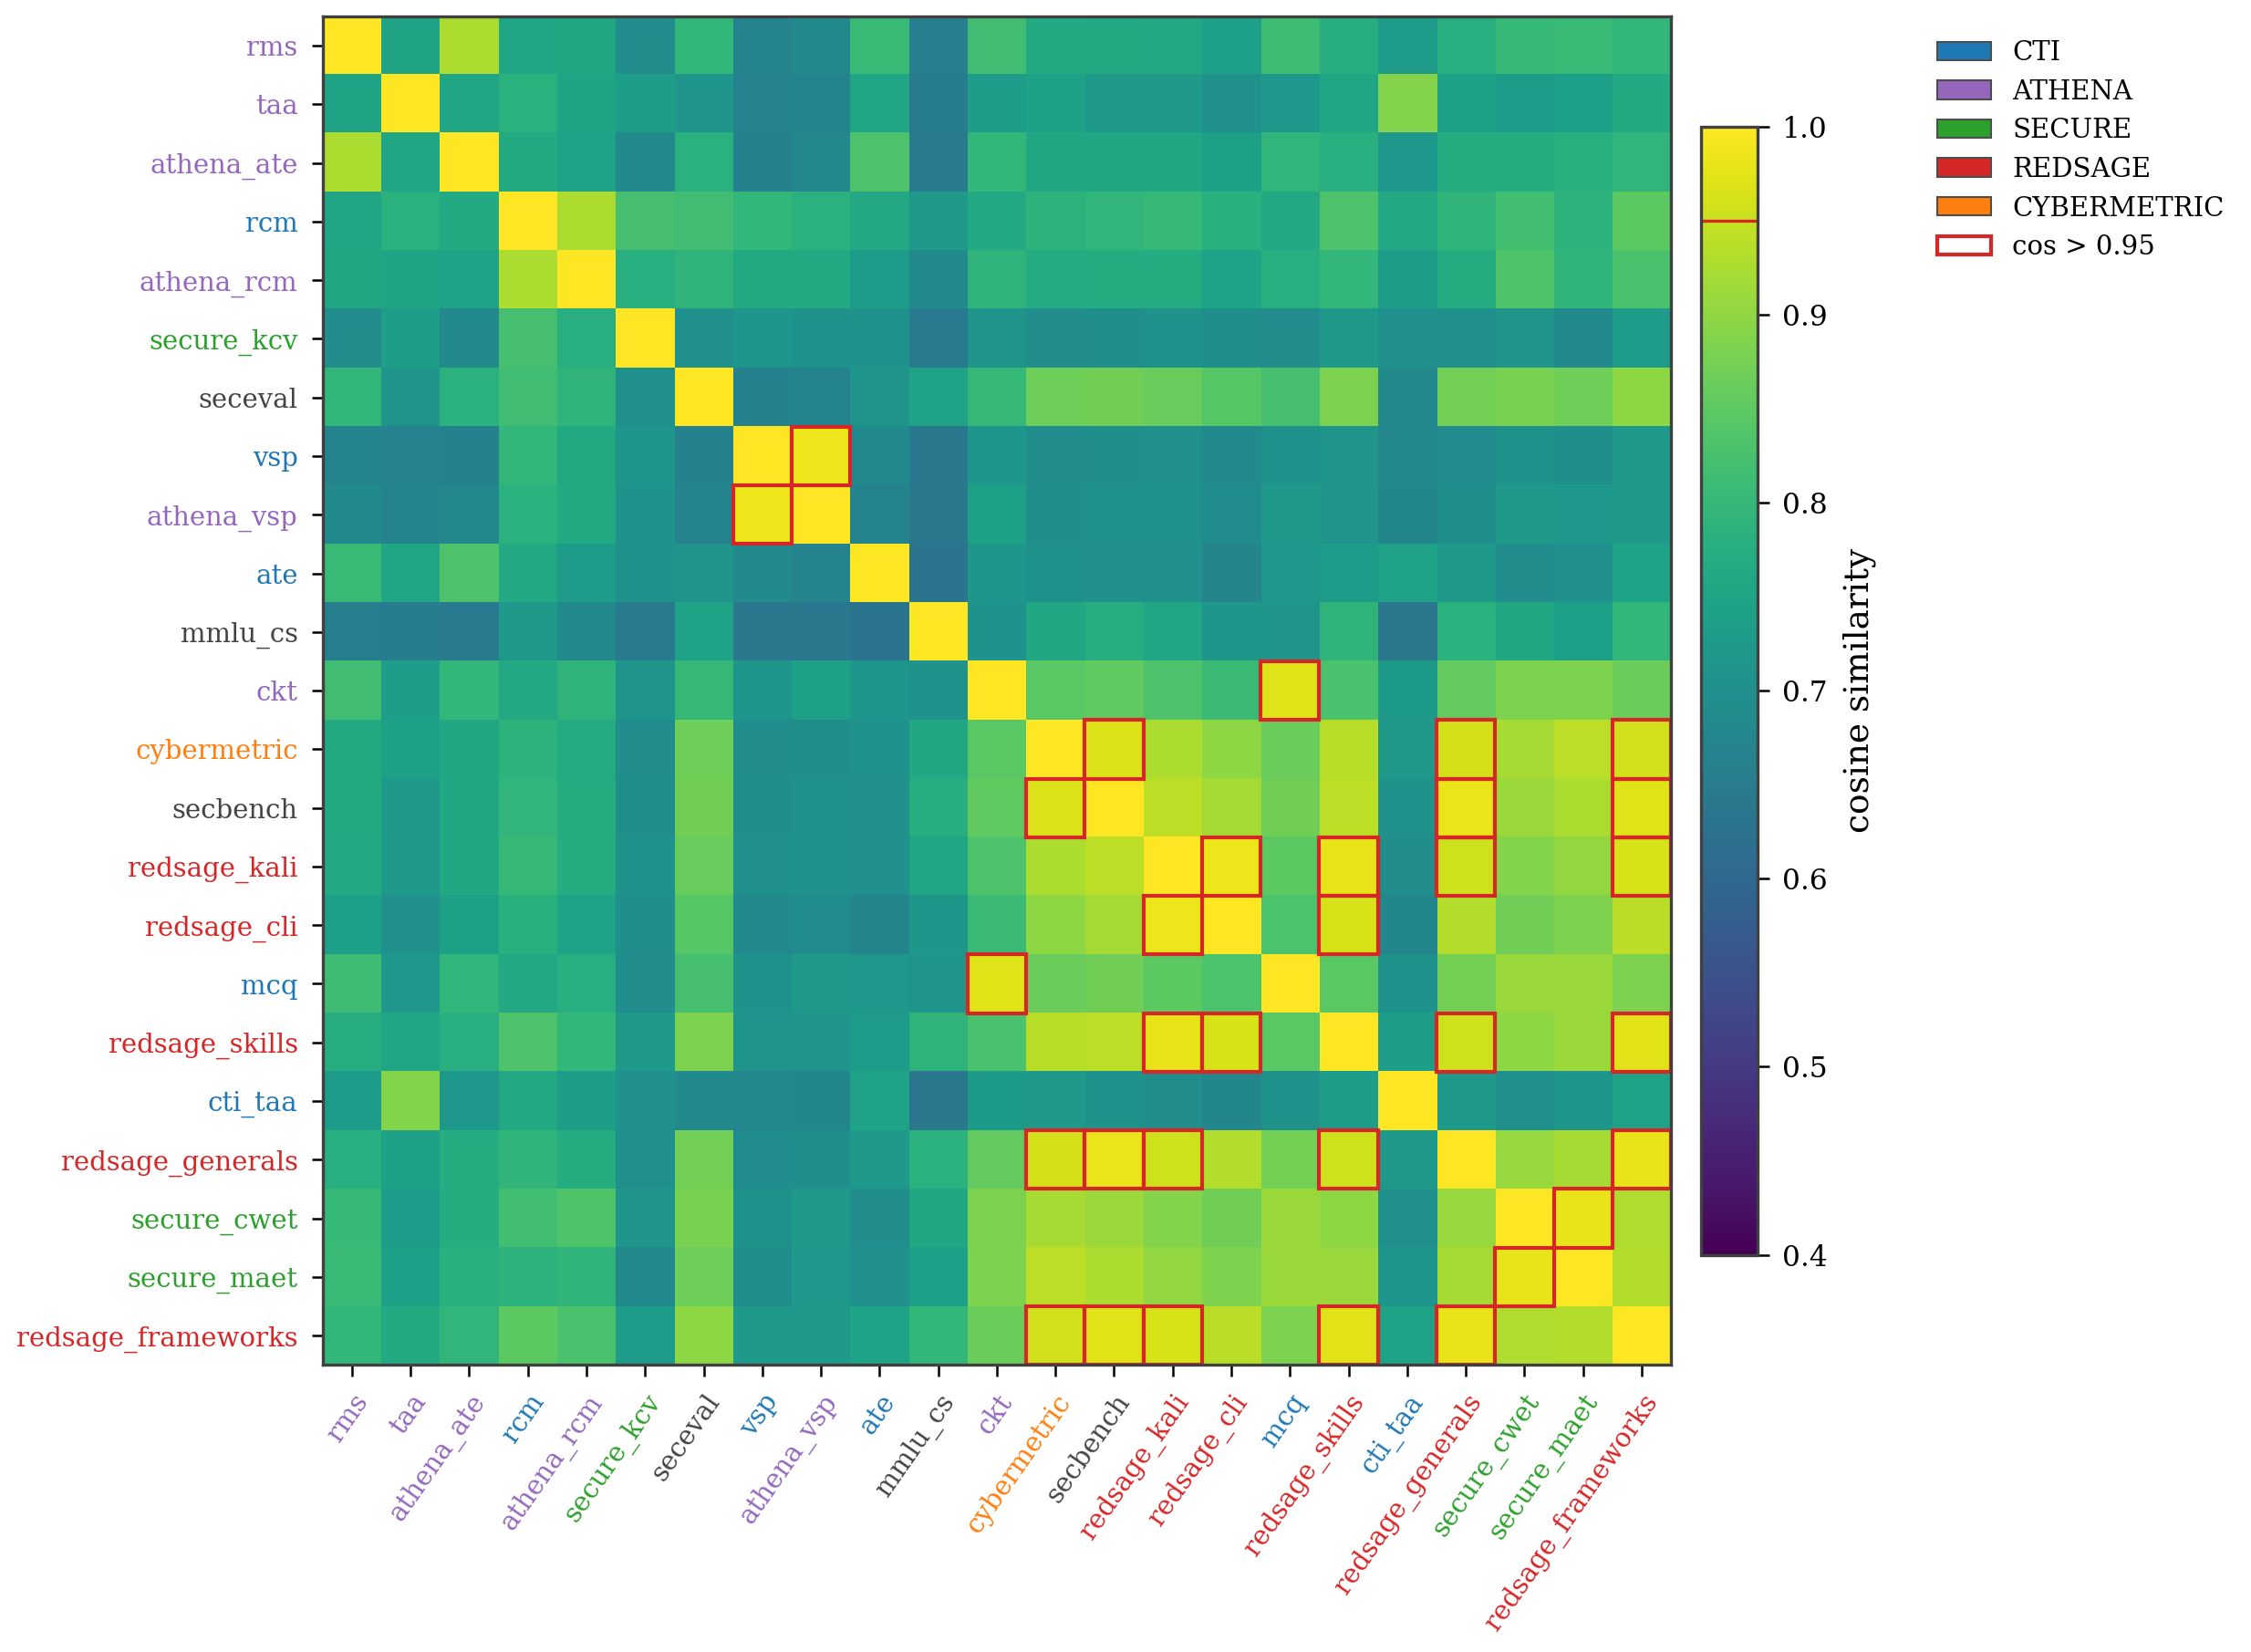

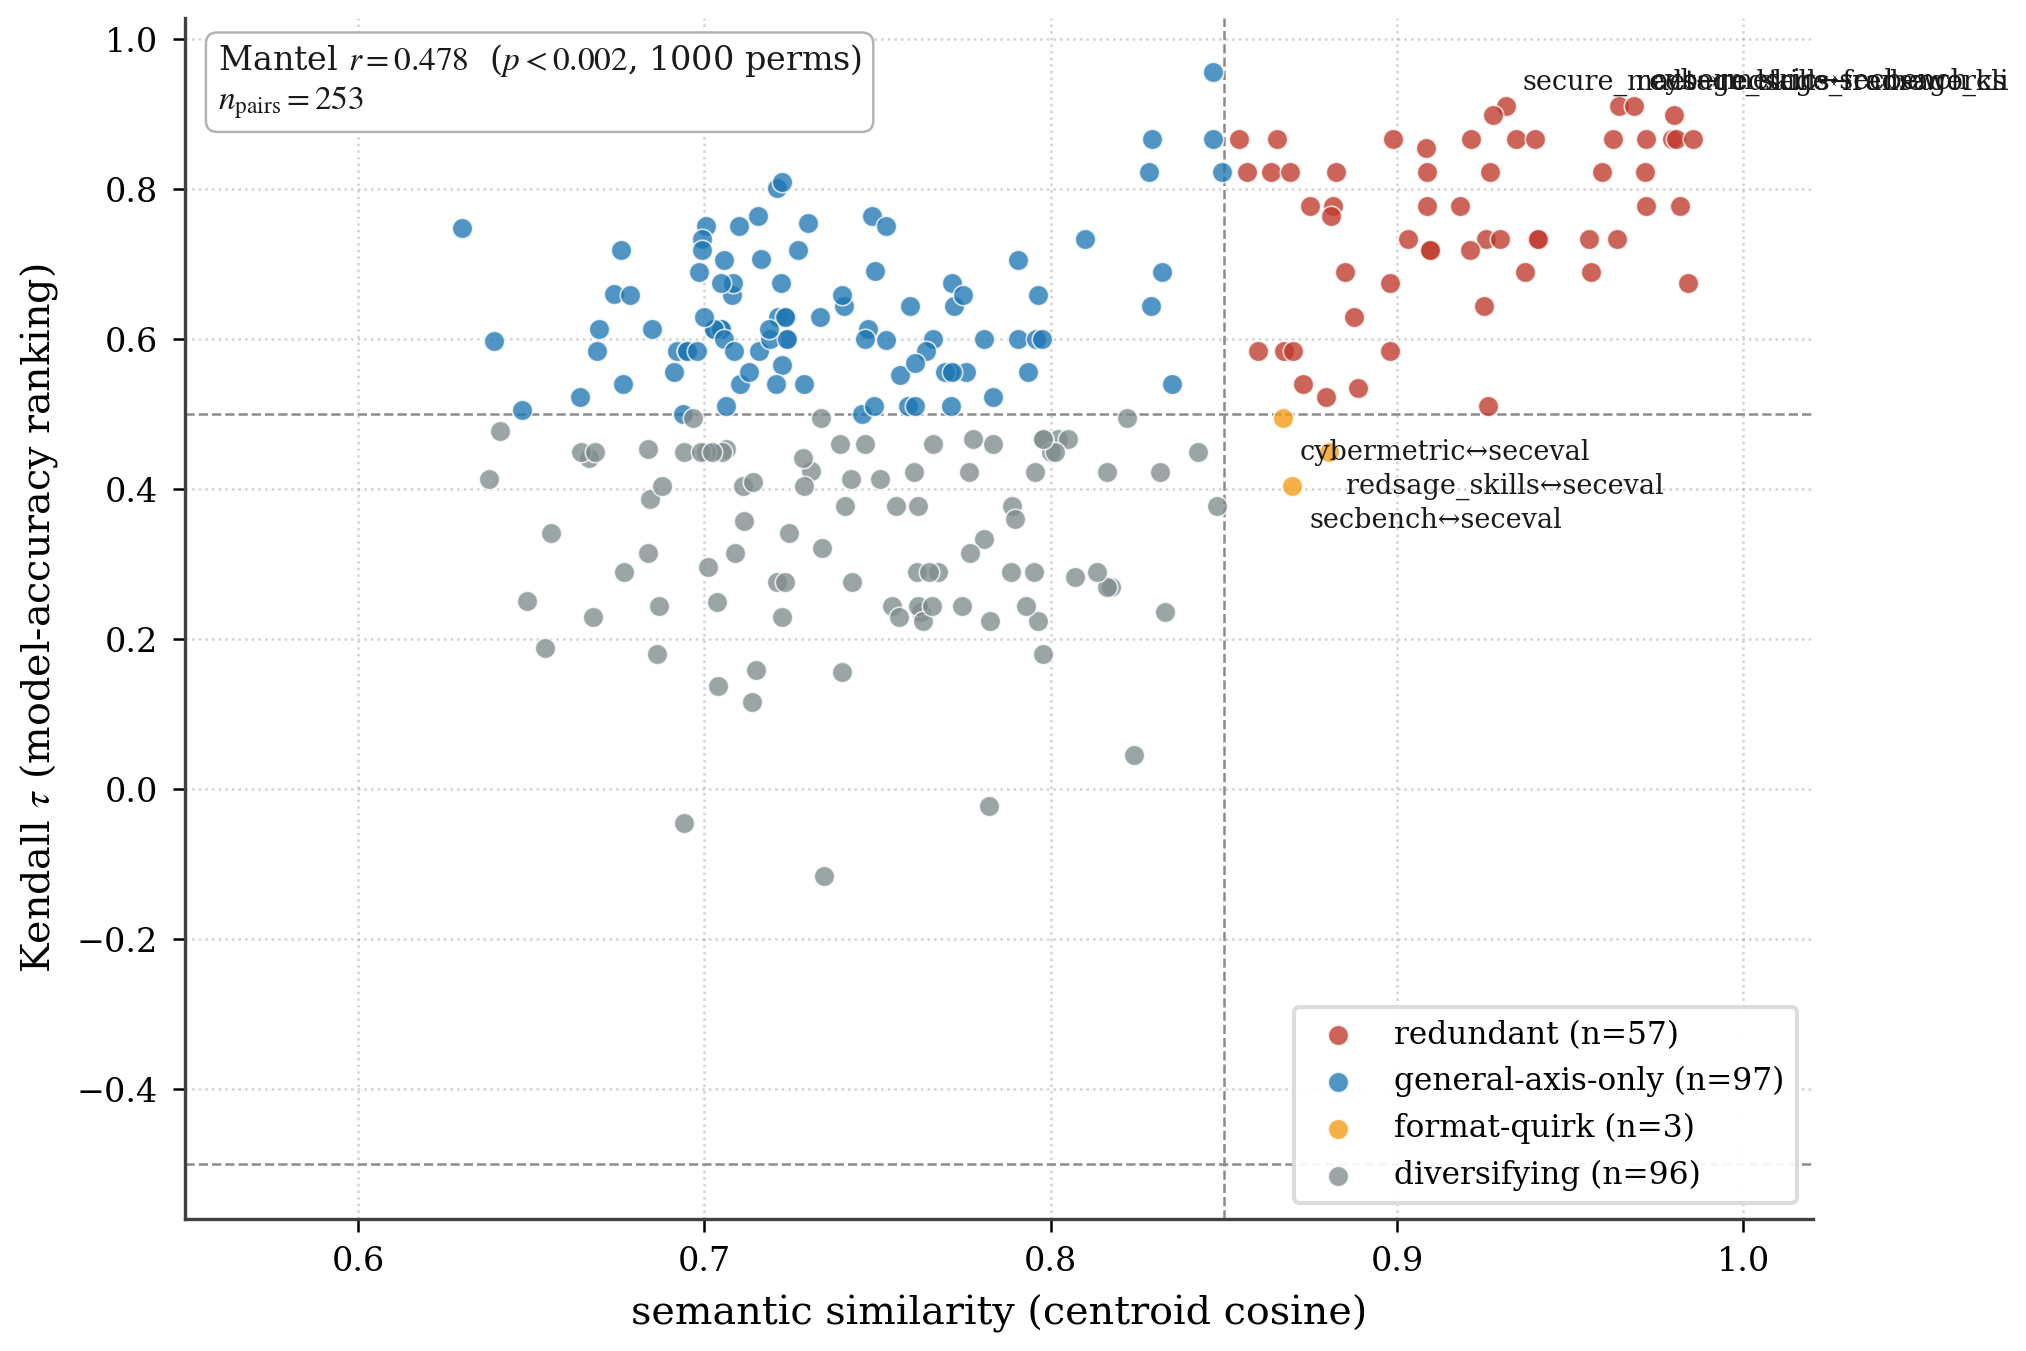

In [6]:
run_mod("embedding_correlation", "analysis.embedding_correlation")
run_mod("make_embed_plots", "analysis.make_embed_plots")
show_df("embeddings/centroid_similarity.csv")
show_fig("centroid_similarity_heatmap.png")
show_fig("semantic_vs_accuracy_scatter.png")

_The effective-dimension and semantic-overlap evidence for benchmark redundancy._